In [1]:
import os
import numpy as np
import rasterio
from rasterio import plot
from rasterio.plot import show
import json
from natsort import natsorted
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from utils.image_pre_process import normalized_difference, stack_bands, stack_to_geotiff, get_bands, aoi_geojson_reader, aoi_geojson_reader, geojson_to_pixel_polygons, visualize_image_with_polygons, histogram_match, sam_change_detection
from example_change_detection import compute_change_distance

In [2]:
raster_path_1 = "data/sentinel2_20230812"
raster_path_2 = "data/sentinel2_20230902"

In [3]:
output_1 = 'data/processed/geotiff_old.tif'
output_2 = 'data/processed/geotiff_new.tif'
output_hm = 'data/processed/geotiff_hm.tif'
geojson_path = 'aoi.geojson'

In [4]:
bands_1 = get_bands(raster_path_1)
bands_2 = get_bands(raster_path_2)
# bands

{'B02': 'data/sentinel2_20230812/B02.tif', 'B03': 'data/sentinel2_20230812/B03.tif', 'B04': 'data/sentinel2_20230812/B04.tif'}
{'B02': 'data/sentinel2_20230902/B02.tif', 'B03': 'data/sentinel2_20230902/B03.tif', 'B04': 'data/sentinel2_20230902/B04.tif'}


In [5]:
list_of_bands = ['B02', 'B03', 'B04']
stack_1, raster_meta_1 = stack_bands(list_of_bands, bands_1)
stack_2, raster_meta_2 = stack_bands(list_of_bands, bands_2)

<open DatasetReader name='data/sentinel2_20230812/B02.tif' mode='r'> 
 0.0 
 EPSG:32735 
 | 10.00, 0.00, 368430.00|
| 0.00,-10.00, 8653770.00|
| 0.00, 0.00, 1.00| 

<open DatasetReader name='data/sentinel2_20230902/B02.tif' mode='r'> 
 0.0 
 EPSG:32735 
 | 10.00, 0.00, 368430.00|
| 0.00,-10.00, 8653770.00|
| 0.00, 0.00, 1.00| 



In [6]:
stack_to_geotiff(stack_1, raster_meta_1, output_1)
stack_to_geotiff(stack_2, raster_meta_1, output_2)

# histogram match pre-processing
source = stack_2
reference = stack_1
image_hm = histogram_match(source, reference)
stack_to_geotiff(image_hm, raster_meta_1, output_hm)

In [23]:
# stack = stack.astype(np.float32)
# demo algorythm
change_detection = compute_change_distance(stack_1.astype(np.float32), stack_2.astype(np.float32))
change_detection_w_histm = compute_change_distance(stack_1.astype(np.float32), image_hm.astype(np.float32))

change_detection_sam = sam_change_detection(stack_1.astype(np.float32), stack_2.astype(np.float32))
change_detection_sam_w_histm = sam_change_detection(stack_1.astype(np.float32), image_hm.astype(np.float32))

In [51]:
stack_to_geotiff(change_detection[0], raster_meta_1, 'data/processed/change.tif')
stack_to_geotiff(change_detection[1], raster_meta_1, 'data/processed/change_probability.tif')

stack_to_geotiff(change_detection_sam[0], raster_meta_1, 'data/processed/change_sam.tif')
stack_to_geotiff(change_detection_sam[1], raster_meta_1, 'data/processed/change_probability_sam.tif')

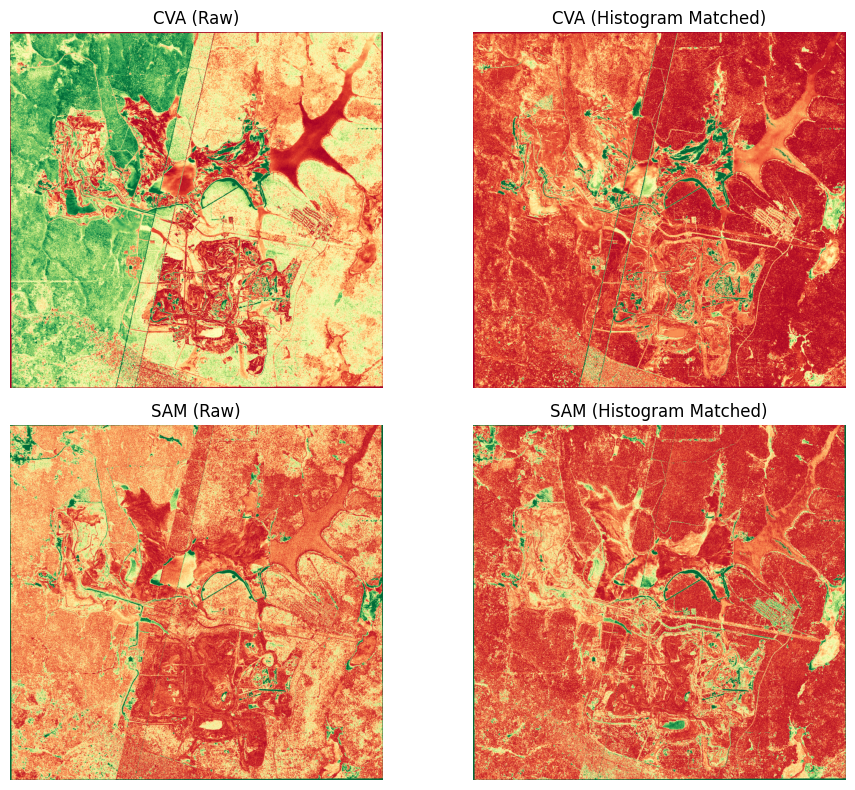

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(change_detection[0], cmap="RdYlGn", vmin=np.percentile(change_detection[0], 2), vmax=np.percentile(change_detection[0], 98))
axes[0, 0].set_title("CVA (Raw)")
axes[0, 0].axis("off")

axes[0, 1].imshow(change_detection_w_histm[0], cmap="RdYlGn", vmin=np.percentile(change_detection_w_histm[0], 2), vmax=np.percentile(change_detection_w_histm[0], 98))
axes[0, 1].set_title("CVA (Histogram Matched)")
axes[0, 1].axis("off")

axes[1, 0].imshow(change_detection_sam[0], cmap="RdYlGn", vmin=np.percentile(change_detection_sam[0], 2), vmax=np.percentile(change_detection_sam[0], 98))
axes[1, 0].set_title("SAM (Raw)")
axes[1, 0].axis("off")

axes[1, 1].imshow(change_detection_sam_w_histm[0], cmap="RdYlGn", vmin=np.percentile(change_detection_sam_w_histm[0], 2), vmax=np.percentile(change_detection_sam_w_histm[0], 98))
axes[1, 1].set_title("SAM (Histogram Matched)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

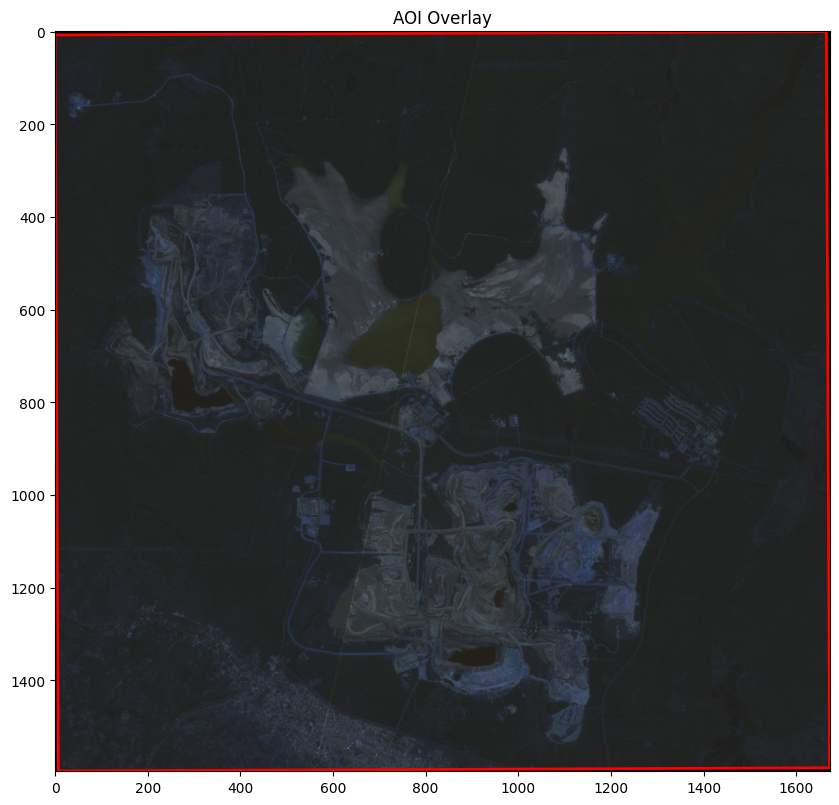

In [37]:
geojson_dict = aoi_geojson_reader(geojson_path)

pixel_polygons = geojson_to_pixel_polygons(geojson_dict, raster_meta_1)

visualize_image_with_polygons(stack_1, pixel_polygons, title="AOI Overlay")